In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/ecommerce.csv')
df.sample(5)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
413,elizabethnunez@vasquez-nelson.net,"209 Andrew Viaduct\nPort Anna, OR 01627-8037",Cornsilk,32.592093,10.314718,36.729029,4.791109,493.181261
342,pamelahampton@martin-cobb.com,"91542 Jessica Springs Suite 255\nThomashaven, ...",DarkSeaGreen,32.342796,11.409645,35.777782,3.872432,486.083426
67,craigcastro@burgess.com,"65407 Warner Forges Suite 071\nNew Lori, AZ 30...",OrangeRed,32.805220,11.835476,36.375066,3.439591,469.310861
28,tinasmith@martinez.info,"40000 Ann Port Suite 474\nYoungberg, MS 03651",LemonChiffon,33.110205,11.982045,35.293088,3.923489,529.537665
456,dvasquez@wiley.com,"967 Chloe Springs Suite 554\nLake Ashley, GA 0...",HoneyDew,32.767076,11.076259,34.779751,2.574948,388.940549


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


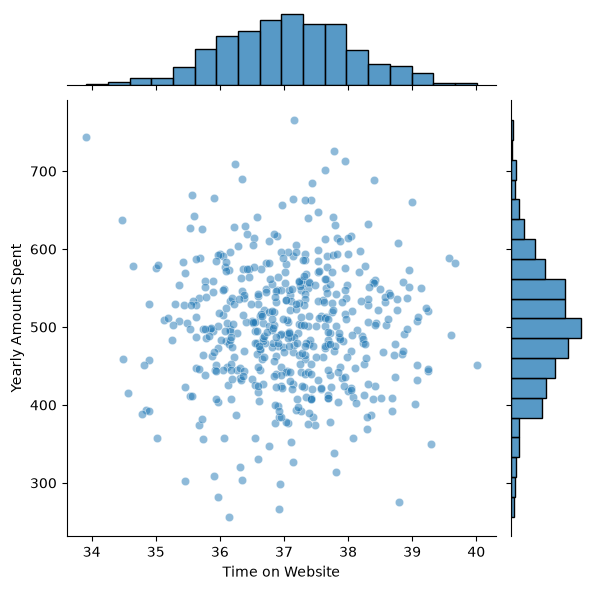

In [10]:
sns.jointplot(x='Time on Website', y='Yearly Amount Spent', data = df, alpha = 0.5)
plt.show()

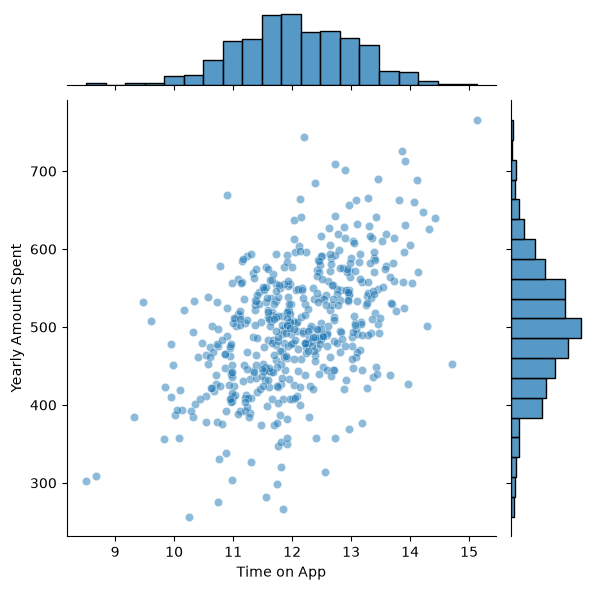

In [11]:
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data = df, alpha = 0.5)
plt.show()

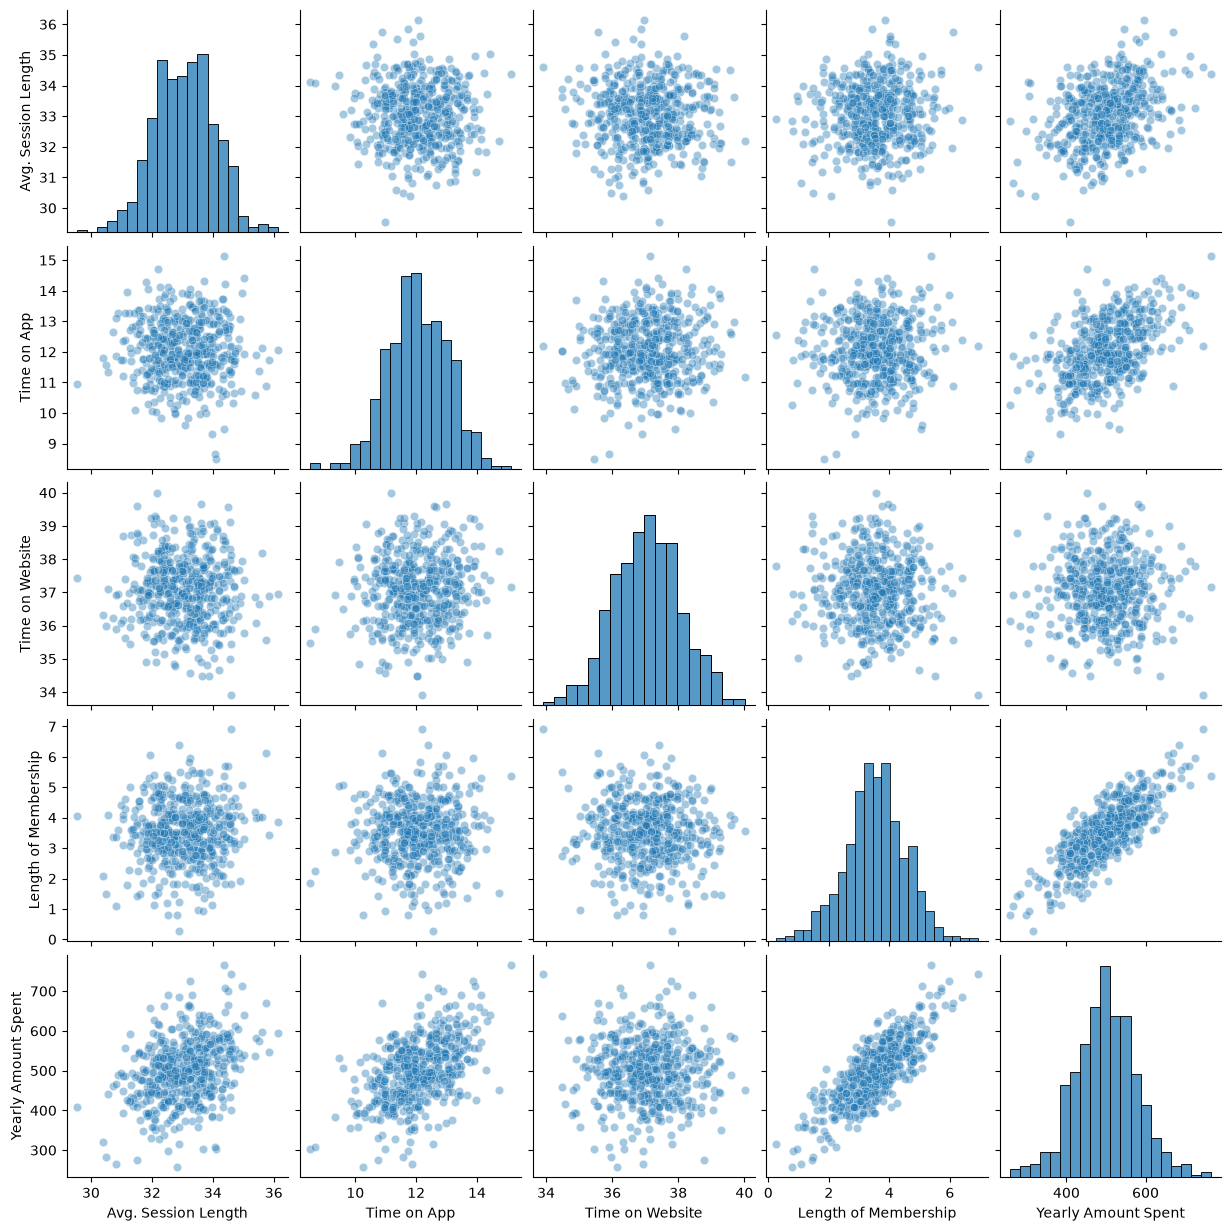

In [14]:
sns.pairplot(data = df, kind='scatter', plot_kws = {'alpha': 0.4})
plt.show()

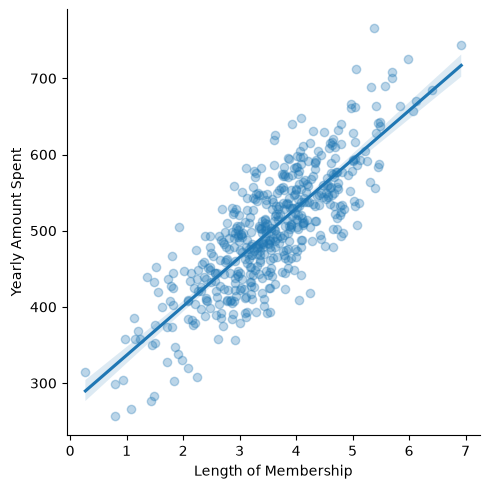

In [15]:
sns.lmplot(x = 'Length of Membership', y = 'Yearly Amount Spent', data = df, scatter_kws = {'alpha': 0.3})
plt.show()

In [20]:
df.drop(columns = ['Email', 'Address', 'Avatar'], inplace = True)

In [ ]:
X = df.drop(columns = 'Yearly Amount Spent')
y = df['Yearly Amount Spent']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [27]:
numeric_cols = X_train.select_dtypes(include = 'number').columns.tolist()
numeric_pipeline = Pipeline([
    ('scaler', MinMaxScaler())
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols )
])

In [28]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conca

In [30]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 8.426091641432095
RMSE: 10.193897260863139
R2: 0.9808757641125856


In [33]:
coeficientes = model.named_steps["model"].coef_
intercepto = model.named_steps["model"].intercept_

print(f"Coeficientes: {coeficientes}")
print(f"Intercepto: {intercepto}")

Coeficientes: [162.77814254 255.46834573   2.64411494 410.30893493]
Intercepto: 69.65394510489119


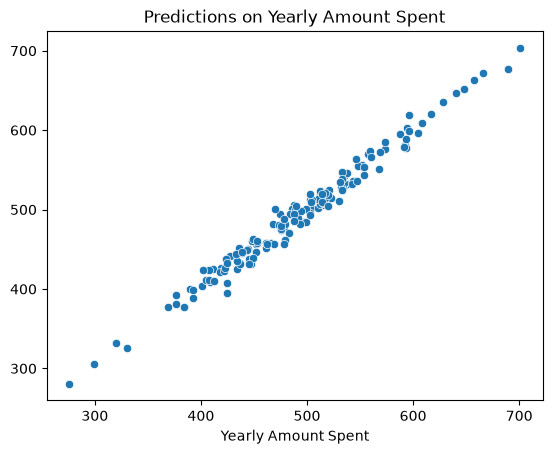

In [41]:
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Predictions on Yearly Amount Spent')
plt.show()

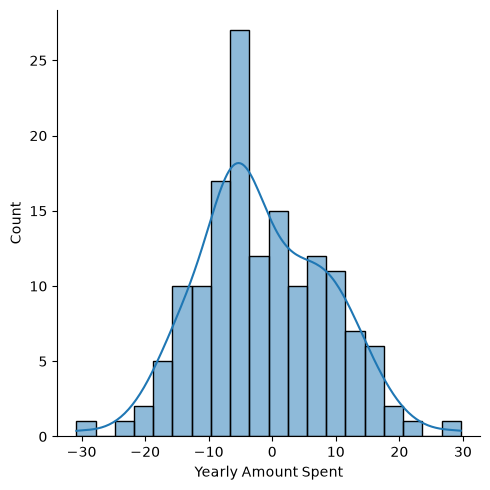

In [38]:
residuals = y_test - y_pred

sns.displot(residuals, bins = 20, kde = True)
plt.show()

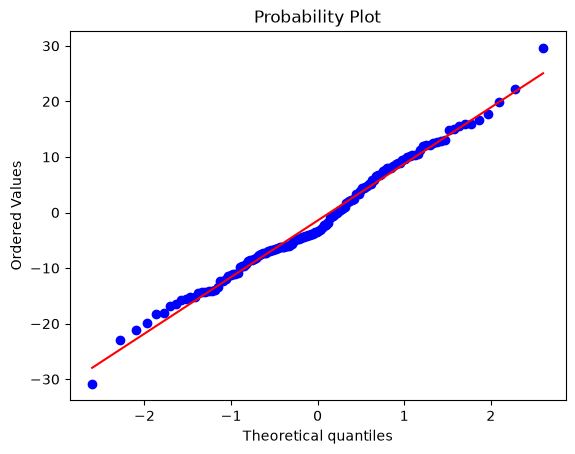

In [39]:
import pylab
import scipy.stats as stats 

stats.probplot(residuals, dist = 'norm', plot = pylab)
pylab.show()